In [1]:
import requests
import pandas as pd
import numpy as np
import pytensor.tensor as pt
import time


from sklearn.preprocessing import StandardScaler, OneHotEncoder, minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA

import pymc as pm
import arviz as az

import nutpie


# FPL API Fetch


In [2]:
def find_my_leagues(manager_id):
    """
    Finds all league IDs (Classic and H2H) for a given manager.
    Use this to discover your H2H_LEAGUE_ID.
    """
    url = f"https://fantasy.premierleague.com/api/entry/{manager_id}/"
    print(f"Searching leagues for Manager {manager_id}...")

    try:
        r = requests.get(url)
        if r.status_code != 200:
            print(f"Failed to fetch data for manager {manager_id}")
            return

        data = r.json()
        leagues = data.get('leagues', {})

        print("\n--- H2H Leagues ---")
        for league in leagues.get('h2h', []):
            print(f"Name: {league['name']} | ID: {league['id']}")

        # print("\n--- Classic Leagues ---")
        # for league in leagues.get('classic', []):
        #     print(f"Name: {league['name']} | ID: {league['id']}")

    except Exception as e:
        print(f"Error: {e}")

def fetch_h2h_opponent(manager_id, league_id, gameweek):
    """
    Given a manager ID and H2H league ID, finds the opponent's manager ID
    by iterating through all pages of the matches endpoint.
    """
    page = 1
    print(f"Searching for H2H opponent for Manager {manager_id} in GW {gameweek}...")

    while True:
        url = f"https://fantasy.premierleague.com/api/leagues-h2h-matches/league/{league_id}/?page={page}&event={gameweek}"
        try:
            r = requests.get(url)
            if r.status_code != 200:
                print(f"Error fetching page {page}. Status: {r.status_code}")
                break

            data = r.json()
            matches = data.get('results', [])

            if not matches:
                break

            for match in matches:
                if match['entry_1_entry'] == manager_id:
                    return match['entry_2_entry']
                elif match['entry_2_entry'] == manager_id:
                    return match['entry_1_entry']

            if not data.get('has_next'):
                break

            page += 1
            time.sleep(0.2) # Avoid hitting rate limits during pagination
        except Exception as e:
            print(f"Error on page {page}: {e}")
            break

    print("Match not found in any of the league pages.")
    return None


def fetch_manager_history(manager_id, current_gw):
    """
    Fetches the historical team selections (picks) for a specific FPL manager.

    Args:
        manager_id (int): The unique ID of the FPL manager.
        current_gw (int): The most recent completed Gameweek.

    Returns:
        pd.DataFrame: A long-format DataFrame containing player IDs,
                      positions (starter/bench), and captaincy per GW.
    """
    base_url = "https://fantasy.premierleague.com/api/entry/{}/event/{}/picks/"
    all_picks = []
    managers = []

    print(f"Fetching history for Manager {manager_id}...")

    for gw in range(1, current_gw + 1):
        url = base_url.format(manager_id, gw)
        try:
            response = requests.get(url)

            # Rate limiting safety
            if response.status_code == 429:
                print("Rate limit hit. Sleeping for 10 seconds...")
                time.sleep(10)
                response = requests.get(url)

            if response.status_code != 200:
                print(f"Skipping GW {gw}: Status {response.status_code}")
                continue

            data = response.json()
            managers.append({
                'picks': data['picks'],
                'manager_id': manager_id,
                'round': gw,
                'total_points': data['entry_history']['points'],
                'points_on_bench': data['entry_history']['points_on_bench']
            })
            for pick in data['picks']:
                all_picks.append({
                    'manager_id': manager_id,
                    'round': gw,
                    'fpl_id': pick['element'],
                    'position_in_team': pick['position'], # 1-11 are starters, 12-15 bench
                    'multiplier': pick['multiplier'],      # 2 or 3 for captain/TC, 0 for bench
                    'is_captain': pick['is_captain'],
                    'is_vice_captain': pick['is_vice_captain'],
                    'total_points': data['entry_history']['points'],
                    'points_on_bench': data['entry_history']['points_on_bench']
                })

            # Small sleep to be polite to the API
            time.sleep(0.5)

        except Exception as e:
            print(f"Error fetching GW {gw}: {e}")

    df = pd.DataFrame(all_picks)
    manager_df = pd.DataFrame(managers)

    # Add a binary 'is_starter' column for easier modeling
    df['is_starter'] = df['multiplier'] > 0

    return df, manager_df

def get_current_gameweek():
    """Returns the current gameweek ID from the FPL bootstrap-static API."""
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    r = requests.get(url).json()
    for event in r['events']:
        if event['is_current']:
            return event['id']
    return 1


In [3]:
manager_id = 438682 # Example ID (Overall league is usually huge, use a mini-league ID)
league_ids = find_my_leagues(manager_id)
print(league_ids)

Searching leagues for Manager 438682...

--- H2H Leagues ---
Name: EPL-DIEHARDS 2025/26 | ID: 69646
Name: EPL PUNDITS LEAGUE H2H 2025/26 | ID: 117506
Name: Kandanda H2H 2025/26 | ID: 125075
Name: Fantasy experts 25/26🟢 | ID: 126202
Name: H2H - Undefined League 25/26 | ID: 685131
None


In [4]:
OPPONENT_ID = fetch_h2h_opponent(438682, 117506, 23)

latest_gw = get_current_gameweek()

# Fetch all picks from GW1 to now
history_df, hist_manager = fetch_manager_history(OPPONENT_ID, latest_gw)

# Save to CSV for the Dirichlet model
filename = f"manager_{OPPONENT_ID}_history.csv"
history_df.to_csv(filename, index=False)

print(f"Successfully saved {len(history_df)} picks to {filename}")
# print(history_df.head(15)) # Show the first team (GW1)
history_df

Searching for H2H opponent for Manager 438682 in GW 23...
Fetching history for Manager 435495...
Successfully saved 345 picks to manager_435495_history.csv


,manager_id,round,fpl_id,position_in_team,multiplier,is_captain,is_vice_captain,total_points,points_on_bench,is_starter
0,435495,1,502,1,1,False,False,70,10,True
1,435495,1,477,2,1,False,False,70,10,True
2,435495,1,507,3,1,False,False,70,10,True
3,435495,1,575,4,1,False,False,70,10,True
4,435495,1,582,5,1,False,False,70,10,True
...,...,...,...,...,...,...,...,...,...,...
340,435495,23,136,11,1,False,False,37,9,True
341,435495,23,470,12,0,False,False,37,9,False
342,435495,23,691,13,0,False,False,37,9,False
343,435495,23,694,14,0,False,False,37,9,False


In [5]:
hist_manager

,picks,manager_id,round,total_points,points_on_bench
0,"[{'element': 502, 'position': 1, 'multiplier':...",435495,1,70,10
1,"[{'element': 502, 'position': 1, 'multiplier':...",435495,2,48,14
2,"[{'element': 502, 'position': 1, 'multiplier':...",435495,3,61,9
3,"[{'element': 565, 'position': 1, 'multiplier':...",435495,4,87,13
4,"[{'element': 565, 'position': 1, 'multiplier':...",435495,5,54,16
5,"[{'element': 565, 'position': 1, 'multiplier':...",435495,6,83,20
6,"[{'element': 565, 'position': 1, 'multiplier':...",435495,7,83,4
7,"[{'element': 565, 'position': 1, 'multiplier':...",435495,8,94,0
8,"[{'element': 469, 'position': 1, 'multiplier':...",435495,9,59,10
9,"[{'element': 469, 'position': 1, 'multiplier':...",435495,10,62,8


In [6]:

hist_manager['selections'] = hist_manager.apply(lambda row: [pick['element'] for pick in row['picks']], axis=1)
# hist_manager['round'] = hist_manager['round'].values
hist_manager

,picks,manager_id,round,total_points,points_on_bench,selections
0,"[{'element': 502, 'position': 1, 'multiplier':...",435495,1,70,10,"[502, 477, 507, 575, 582, 382, 235, 16, 267, 4..."
1,"[{'element': 502, 'position': 1, 'multiplier':...",435495,2,48,14,"[502, 477, 441, 507, 582, 382, 16, 267, 252, 2..."
2,"[{'element': 502, 'position': 1, 'multiplier':...",435495,3,61,9,"[502, 477, 575, 8, 582, 382, 449, 267, 252, 24..."
3,"[{'element': 565, 'position': 1, 'multiplier':...",435495,4,87,13,"[565, 477, 8, 260, 82, 119, 384, 419, 430, 249..."
4,"[{'element': 565, 'position': 1, 'multiplier':...",435495,5,54,16,"[565, 477, 8, 260, 82, 119, 384, 582, 430, 249..."
5,"[{'element': 565, 'position': 1, 'multiplier':...",435495,6,83,20,"[565, 72, 8, 260, 82, 119, 419, 582, 430, 249,..."
6,"[{'element': 565, 'position': 1, 'multiplier':...",435495,7,83,4,"[565, 72, 8, 260, 82, 119, 582, 16, 430, 666, ..."
7,"[{'element': 565, 'position': 1, 'multiplier':...",435495,8,94,0,"[565, 72, 8, 260, 82, 200, 582, 16, 430, 666, ..."
8,"[{'element': 469, 'position': 1, 'multiplier':...",435495,9,59,10,"[469, 72, 8, 348, 82, 119, 582, 16, 430, 666, ..."
9,"[{'element': 469, 'position': 1, 'multiplier':...",435495,10,62,8,"[469, 694, 8, 260, 82, 119, 582, 16, 430, 666,..."


# FPL Data


In [107]:
data_25_26 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')

cols = [

    'fpl_id', 'round',  'position', 'team', 'opponent_team_name', 'was_home', 'xP', # 'fpl_name', 'team_id', 'xP_next', #'form',  'value_form',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'elo',  'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'cbitr_ewm_90' , 'cbitr_ewm_probability' ,

    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm',
    'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm',
    'assists_1_ewm', 'assists_3_ewm', 'assists_5_ewm', 'goals_1_ewm', 'goals_3_ewm', 'goals_5_ewm', 'expected_goal_involvements_1_ewm',
    'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm', 'strength_overall_home_1_ewm', 'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm',
    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm',
    'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm', 'goals_conceded_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm',
    'ict_index_5_ewm', 'strength_defence_away_1_ewm', 'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm',
    'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm', 'influence_1_ewm', 'influence_3_ewm',
    'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm',
    'transfers_in_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm',
    'selected_by_percent_1_ewm', 'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'red_cards_1_ewm',
    'red_cards_3_ewm', 'red_cards_5_ewm', 'key_passes_1_ewm', 'key_passes_3_ewm', 'key_passes_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'form_1_ewm', 'form_3_ewm',
    'form_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'ownership_change_1_ewm',
    'ownership_change_3_ewm', 'ownership_change_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm', 'pts_bonus_1_ewm',
    'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'transfers_out_1_ewm',
    'transfers_out_3_ewm', 'transfers_out_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm',
    'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength'
    ]

gk_cols = [
    # 'fpl_id', 'round', 'xP',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'elo',  'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm',
    'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'strength_overall_home_1_ewm', 'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm',
    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm',
    'goals_conceded_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm', 'ict_index_5_ewm',
    'strength_defence_away_1_ewm', 'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm', 'influence_1_ewm', 'influence_3_ewm','influence_5_ewm',
    'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm',
    'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm', 'selected_by_percent_1_ewm', 'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm',
    'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'red_cards_1_ewm','red_cards_3_ewm', 'red_cards_5_ewm',  'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'form_1_ewm', 'form_3_ewm',
    'form_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'starts_1_ewm', 'starts_3_ewm','starts_5_ewm',
    'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'ownership_change_1_ewm',
    'ownership_change_3_ewm', 'ownership_change_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm', 'pts_bonus_1_ewm',
    'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'transfers_out_1_ewm',
    'transfers_out_3_ewm', 'transfers_out_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm',
    'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength',

    'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth', 'team_Brentford', 'team_Brighton', 'team_Burnley', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton',
    'team_Fulham', 'team_Leeds', 'team_Liverpool', 'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Spurs', 'team_Sunderland',
    'team_West Ham', 'team_Wolves', 'opponent_team_name_Arsenal', 'opponent_team_name_Aston Villa', 'opponent_team_name_Bournemouth', 'opponent_team_name_Brentford',
    'opponent_team_name_Brighton', 'opponent_team_name_Burnley', 'opponent_team_name_Chelsea', 'opponent_team_name_Crystal Palace', 'opponent_team_name_Everton',
    'opponent_team_name_Fulham', 'opponent_team_name_Leeds', 'opponent_team_name_Liverpool', 'opponent_team_name_Manchester City',
    'opponent_team_name_Manchester United', 'opponent_team_name_Newcastle United', 'opponent_team_name_Nottingham Forest', 'opponent_team_name_Sunderland',
    'opponent_team_name_Tottenham', 'opponent_team_name_West Ham', 'opponent_team_name_Wolverhampton Wanderers',
    'was_home_False', 'was_home_True'

    ]

def_mid_cols = [

    'fpl_id', 'round', 'xP',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'elo',  'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'cbitr_ewm_90' , 'cbitr_ewm_probability' ,

    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm',
    'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm',
    'assists_1_ewm', 'assists_3_ewm', 'assists_5_ewm', 'goals_1_ewm', 'goals_3_ewm', 'goals_5_ewm', 'expected_goal_involvements_1_ewm',
    'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm', 'strength_overall_home_1_ewm', 'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm',
    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm',
    'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm', 'goals_conceded_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm',
    'ict_index_5_ewm', 'strength_defence_away_1_ewm', 'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm',
    'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm', 'influence_1_ewm', 'influence_3_ewm',
    'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm',
    'transfers_in_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm',
    'selected_by_percent_1_ewm', 'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'red_cards_1_ewm',
    'red_cards_3_ewm', 'red_cards_5_ewm', 'key_passes_1_ewm', 'key_passes_3_ewm', 'key_passes_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'form_1_ewm', 'form_3_ewm',
    'form_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'ownership_change_1_ewm',
    'ownership_change_3_ewm', 'ownership_change_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm', 'pts_bonus_1_ewm',
    'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'transfers_out_1_ewm',
    'transfers_out_3_ewm', 'transfers_out_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm',
    'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength',

    'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth', 'team_Brentford', 'team_Brighton', 'team_Burnley', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton',
    'team_Fulham', 'team_Leeds', 'team_Liverpool', 'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Spurs', 'team_Sunderland',
    'team_West Ham', 'team_Wolves', 'opponent_team_name_Arsenal', 'opponent_team_name_Aston Villa', 'opponent_team_name_Bournemouth', 'opponent_team_name_Brentford',
    'opponent_team_name_Brighton', 'opponent_team_name_Burnley', 'opponent_team_name_Chelsea', 'opponent_team_name_Crystal Palace', 'opponent_team_name_Everton',
    'opponent_team_name_Fulham', 'opponent_team_name_Leeds', 'opponent_team_name_Liverpool', 'opponent_team_name_Manchester City',
    'opponent_team_name_Manchester United', 'opponent_team_name_Newcastle United', 'opponent_team_name_Nottingham Forest', 'opponent_team_name_Sunderland',
    'opponent_team_name_Tottenham', 'opponent_team_name_West Ham', 'opponent_team_name_Wolverhampton Wanderers',
    'was_home_False', 'was_home_True'
    ]

fwd_cols = [

    'fpl_id', 'round', 'xP',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'elo',  'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',

    'cbitr_ewm_90' , 'cbitr_ewm_probability' ,

    'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm',
    'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm',
    'assists_1_ewm', 'assists_3_ewm', 'assists_5_ewm', 'goals_1_ewm', 'goals_3_ewm', 'goals_5_ewm', 'expected_goal_involvements_1_ewm',
    'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm', 'strength_overall_home_1_ewm', 'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm',
    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm',
    'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm',
    'ict_index_5_ewm', 'strength_defence_away_1_ewm', 'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm',
    'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm', 'influence_1_ewm', 'influence_3_ewm',
    'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm',
    'transfers_in_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm',
    'selected_by_percent_1_ewm', 'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'red_cards_1_ewm',
    'red_cards_3_ewm', 'red_cards_5_ewm', 'key_passes_1_ewm', 'key_passes_3_ewm', 'key_passes_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'form_1_ewm', 'form_3_ewm',
    'form_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'ownership_change_1_ewm',
    'ownership_change_3_ewm', 'ownership_change_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm', 'pts_bonus_1_ewm',
    'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'transfers_out_1_ewm',
    'transfers_out_3_ewm', 'transfers_out_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm',
    'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength',

    'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth', 'team_Brentford', 'team_Brighton', 'team_Burnley', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton',
    'team_Fulham', 'team_Leeds', 'team_Liverpool', 'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Spurs', 'team_Sunderland',
    'team_West Ham', 'team_Wolves', 'opponent_team_name_Arsenal', 'opponent_team_name_Aston Villa', 'opponent_team_name_Bournemouth', 'opponent_team_name_Brentford',
    'opponent_team_name_Brighton', 'opponent_team_name_Burnley', 'opponent_team_name_Chelsea', 'opponent_team_name_Crystal Palace', 'opponent_team_name_Everton',
    'opponent_team_name_Fulham', 'opponent_team_name_Leeds', 'opponent_team_name_Liverpool', 'opponent_team_name_Manchester City',
    'opponent_team_name_Manchester United', 'opponent_team_name_Newcastle United', 'opponent_team_name_Nottingham Forest', 'opponent_team_name_Sunderland',
    'opponent_team_name_Tottenham', 'opponent_team_name_West Ham', 'opponent_team_name_Wolverhampton Wanderers',
    'was_home_False', 'was_home_True'
    ]


data_25_26 = data_25_26.rename({'web_name': 'fpl_name'}, axis=1)


In [48]:

# hist_data = data_25_26[data_25_26['minutes_3'] > 15]
data = data_25_26[(data_25_26['round'] < 6)].copy()

# data_25_26 = pd.concat([hist_data, tar_data])

active_data = data[cols].copy()
active_data_ = active_data.copy()

CATEGORICAL_COLS = ['team', 'position', 'opponent_team_name', 'was_home']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

cols_ = [*cols, *encoded_cols]
# Combine with numerical data
active_data_ = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)


active_data_.loc[:, 'value'] = active_data_['value']/10
active_data_.loc[:, 'selected_by_percent'] = active_data_['selected_by_percent']/100
active_data_

,fpl_id,round,xP,selected_by_percent,value,transfers_in,transfers_out,selected,ownership_change,percenatge_net_transfers,...,opponent_team_name_Manchester City,opponent_team_name_Manchester United,opponent_team_name_Newcastle United,opponent_team_name_Nottingham Forest,opponent_team_name_Sunderland,opponent_team_name_Tottenham,opponent_team_name_West Ham,opponent_team_name_Wolverhampton Wanderers,was_home_False,was_home_True
0,1.0,1,4.2,0.369,5.5,3072169.0,1125554.0,1531911.0,0.0,0.463731,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,2,9.0,0.215,5.5,354674.0,120510.0,2284634.0,752723.0,0.492786,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,3,5.5,0.218,5.5,108234.0,114694.0,2406964.0,122330.0,-0.028978,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,4,6.5,0.235,5.5,283354.0,128620.0,2765759.0,358795.0,0.375592,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,5,4.0,0.240,5.5,160846.0,111953.0,2762632.0,-3127.0,0.179227,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6596,732.0,4,2.3,0.000,5.5,1809.0,345.0,1703.0,1703.0,0.679666,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6623,734.0,4,1.6,0.000,6.0,746.0,197.0,613.0,613.0,0.582185,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6624,734.0,5,1.5,0.000,6.0,752.0,264.0,1490.0,877.0,0.480315,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6642,736.0,4,4.5,0.017,5.5,168077.0,15792.0,130334.0,130334.0,0.828226,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [75]:
gk_data = active_data_[(active_data_['position_GK'] == 1) & (active_data_['round'] <= 6)][gk_cols] #.drop(['position'], axis=1)
def_data = active_data_[(active_data_['position_DEF'] == 1) & (active_data_['round'] <= 6)][def_mid_cols]#.drop(['position'], axis=1)
mid_data = active_data_[(active_data_['position_MID'] == 1) & (active_data_['round'] <= 6)][def_mid_cols]#.drop(['position'], axis=1)
fwd_data = active_data_[(active_data_['position_FWD'] == 1) & (active_data_['round'] <= 6)][fwd_cols]#.drop(['position'], axis=1)

gk_ids = gk_data['fpl_id'].unique().tolist()
def_ids = def_data['fpl_id'].unique().tolist()
mid_ids = mid_data['fpl_id'].unique().tolist()
fwd_ids = fwd_data['fpl_id'].unique().tolist()

gk_data_num = gk_data.drop(columns=['fpl_id', 'round', 'xP'])
def_data_num = def_data.drop(columns=['fpl_id', 'round', 'xP'])
mid_data_num = mid_data.drop(columns=['fpl_id', 'round', 'xP'])
fwd_data_num = fwd_data.drop(columns=['fpl_id', 'round', 'xP'])

gk_data_num_scaled = pd.DataFrame(minmax_scale(gk_data_num), columns=gk_data_num.columns, index=gk_data_num.index)
def_data_num_scaled = pd.DataFrame(minmax_scale(def_data_num), columns=def_data_num.columns, index=def_data_num.index)
mid_data_num_scaled = pd.DataFrame(minmax_scale(mid_data_num), columns=mid_data_num.columns, index=mid_data_num.index)
fwd_data_num_scaled = pd.DataFrame(minmax_scale(fwd_data_num), columns=fwd_data_num.columns, index=fwd_data_num.index)

# gk_data_scaled = pd.concat([gk_data[['fpl_id', 'round']], gk_data_num_scaled], axis=1)
# def_data_scaled = pd.concat([def_data[['fpl_id', 'round']], def_data_num_scaled], axis=1)
# mid_data_scaled = pd.concat([mid_data[['fpl_id', 'round']], mid_data_num_scaled], axis=1)
# fwd_data_scaled = pd.concat([fwd_data[['fpl_id', 'round']], fwd_data_num_scaled], axis=1)

# Selection percentages
gk_select_by = gk_data_num_scaled['selected_by_percent']
def_select_by = def_data_num_scaled['selected_by_percent']
mid_select_by = mid_data_num_scaled['selected_by_percent']
fwd_select_by = fwd_data_num_scaled['selected_by_percent']


# Normalise the select_percts to get the working probs
gk_probs = np.clip(gk_select_by/np.sum(gk_select_by), 1e-5, 1.0)
def_probs = np.clip(def_select_by/np.sum(def_select_by), 1e-5, 1.0)
mid_probs = np.clip(mid_select_by/np.sum(mid_select_by), 1e-5, 1.0)
fwd_probs = np.clip(fwd_select_by/np.sum(fwd_select_by), 1e-5, 1.0)


gk_data_scaled = gk_data_num_scaled.drop(columns='selected_by_percent')
def_data_scaled = def_data_num_scaled.drop(columns='selected_by_percent')
mid_data_scaled = mid_data_num_scaled.drop(columns='selected_by_percent')
fwd_data_scaled = fwd_data_num_scaled.drop(columns='selected_by_percent')

gk_data_scaled[['fpl_id', 'round', 'selected_by_percent']] = gk_data[['fpl_id', 'round', 'selected_by_percent']]
def_data_scaled[['fpl_id', 'round', 'selected_by_percent']] = def_data[['fpl_id', 'round', 'selected_by_percent']]
mid_data_scaled[['fpl_id', 'round', 'selected_by_percent']] = mid_data[['fpl_id', 'round', 'selected_by_percent']]
fwd_data_scaled[['fpl_id', 'round', 'selected_by_percent']] = fwd_data[['fpl_id', 'round', 'selected_by_percent']]


In [60]:
hist_manager

,picks,manager_id,round,total_points,points_on_bench,selections
0,"[{'element': 502, 'position': 1, 'multiplier':...",435495,1,70,10,"[502, 477, 507, 575, 582, 382, 235, 16, 267, 4..."
1,"[{'element': 502, 'position': 1, 'multiplier':...",435495,2,48,14,"[502, 477, 441, 507, 582, 382, 16, 267, 252, 2..."
2,"[{'element': 502, 'position': 1, 'multiplier':...",435495,3,61,9,"[502, 477, 575, 8, 582, 382, 449, 267, 252, 24..."
3,"[{'element': 565, 'position': 1, 'multiplier':...",435495,4,87,13,"[565, 477, 8, 260, 82, 119, 384, 419, 430, 249..."
4,"[{'element': 565, 'position': 1, 'multiplier':...",435495,5,54,16,"[565, 477, 8, 260, 82, 119, 384, 582, 430, 249..."
5,"[{'element': 565, 'position': 1, 'multiplier':...",435495,6,83,20,"[565, 72, 8, 260, 82, 119, 419, 582, 430, 249,..."
6,"[{'element': 565, 'position': 1, 'multiplier':...",435495,7,83,4,"[565, 72, 8, 260, 82, 119, 582, 16, 430, 666, ..."
7,"[{'element': 565, 'position': 1, 'multiplier':...",435495,8,94,0,"[565, 72, 8, 260, 82, 200, 582, 16, 430, 666, ..."
8,"[{'element': 469, 'position': 1, 'multiplier':...",435495,9,59,10,"[469, 72, 8, 348, 82, 119, 582, 16, 430, 666, ..."
9,"[{'element': 469, 'position': 1, 'multiplier':...",435495,10,62,8,"[469, 694, 8, 260, 82, 119, 582, 16, 430, 666,..."


In [67]:
hist_manager['gk_picks'] = hist_manager.apply(lambda row: [player for player in row['selections'] if player in gk_ids ], axis=1)
hist_manager['def_picks'] = hist_manager.apply(lambda row: [player for player in row['selections'] if player in def_ids ], axis=1)
hist_manager['mid_picks'] = hist_manager.apply(lambda row: [player for player in row['selections'] if player in mid_ids ], axis=1)
hist_manager['fwd_picks'] = hist_manager.apply(lambda row: [player for player in row['selections'] if player in fwd_ids ], axis=1)
hist_manager

,picks,manager_id,round,total_points,points_on_bench,selections,gk_picks,def_picks,mid_picks,fwd_picks
0,"[{'element': 502, 'position': 1, 'multiplier':...",435495,1,70,10,"[502, 477, 507, 575, 582, 382, 235, 16, 267, 4...","[502, 470]","[477, 507, 575, 441, 348]","[582, 382, 235, 16, 267]","[430, 249, 252]"
1,"[{'element': 502, 'position': 1, 'multiplier':...",435495,2,48,14,"[502, 477, 441, 507, 582, 382, 16, 267, 252, 2...","[502, 470]","[477, 441, 507, 575, 348]","[582, 382, 16, 267, 235]","[252, 249, 430]"
2,"[{'element': 502, 'position': 1, 'multiplier':...",435495,3,61,9,"[502, 477, 575, 8, 582, 382, 449, 267, 252, 24...","[502, 470]","[477, 575, 8, 441, 348]","[582, 382, 449, 267, 235]","[252, 249, 430]"
3,"[{'element': 565, 'position': 1, 'multiplier':...",435495,4,87,13,"[565, 477, 8, 260, 82, 119, 384, 419, 430, 249...","[565, 470]","[477, 8, 260, 72, 348]","[82, 119, 384, 419, 582]","[430, 249, 666]"
4,"[{'element': 565, 'position': 1, 'multiplier':...",435495,5,54,16,"[565, 477, 8, 260, 82, 119, 384, 582, 430, 249...","[565, 470]","[477, 8, 260, 72, 348]","[82, 119, 384, 582, 419]","[430, 249, 666]"
5,"[{'element': 565, 'position': 1, 'multiplier':...",435495,6,83,20,"[565, 72, 8, 260, 82, 119, 419, 582, 430, 249,...","[565, 470]","[72, 8, 260, 477, 348]","[82, 119, 419, 582, 200]","[430, 249, 666]"
6,"[{'element': 565, 'position': 1, 'multiplier':...",435495,7,83,4,"[565, 72, 8, 260, 82, 119, 582, 16, 430, 666, ...","[565, 470]","[72, 8, 260, 683, 348]","[82, 119, 582, 16, 200]","[430, 666, 249]"
7,"[{'element': 565, 'position': 1, 'multiplier':...",435495,8,94,0,"[565, 72, 8, 260, 82, 200, 582, 16, 430, 666, ...","[565, 470]","[72, 8, 260, 694, 348]","[82, 200, 582, 16, 119]","[430, 666, 249]"
8,"[{'element': 469, 'position': 1, 'multiplier':...",435495,9,59,10,"[469, 72, 8, 348, 82, 119, 582, 16, 430, 666, ...","[469, 470]","[72, 8, 348, 260, 694]","[82, 119, 582, 16, 200]","[430, 666, 249]"
9,"[{'element': 469, 'position': 1, 'multiplier':...",435495,10,62,8,"[469, 694, 8, 260, 82, 119, 582, 16, 430, 666,...","[469, 470]","[694, 8, 260, 72, 348]","[82, 119, 582, 16, 200]","[430, 666, 714]"


In [76]:
history_df

,manager_id,round,fpl_id,position_in_team,multiplier,is_captain,is_vice_captain,total_points,points_on_bench,is_starter
0,435495,1,502,1,1,False,False,70,10,True
1,435495,1,477,2,1,False,False,70,10,True
2,435495,1,507,3,1,False,False,70,10,True
3,435495,1,575,4,1,False,False,70,10,True
4,435495,1,582,5,1,False,False,70,10,True
...,...,...,...,...,...,...,...,...,...,...
340,435495,23,136,11,1,False,False,37,9,True
341,435495,23,470,12,0,False,False,37,9,False
342,435495,23,691,13,0,False,False,37,9,False
343,435495,23,694,14,0,False,False,37,9,False


# Get Betas


In [10]:
def fit_dirichlet_regression(X, P_observed):
    """
    Fits a Bayesian Dirichlet regression model using PyMC to estimate beta coefficients.


    Args:
        X (np.ndarray): The feature matrix for a specific position (e.g., GKs).
                        Shape should be (num_players, num_features).
        P_observed (np.ndarray): The observed historical ownership proportions for that position.
                                 Shape should be (num_players,). Must sum to 1.

    Returns:
        pm.backends.base.MultiTrace: The results of the MCMC simulation, containing posterior samples for beta.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Define priors for our beta coefficients. We'll use a flat (uninformative) prior as mentioned.
        # [span_0](start_span)This corresponds to p(beta) in equation (6)[span_0](end_span).
        # betas = pm.Uniform("betas", lower=-5, upper=5, shape=(n_features,)) #
        betas = pm.Normal("betas", mu=0, sigma=1, shape=(n_features,))

        # 2. Calculate alpha based on the linear model: alpha = exp(X * beta)
        # [span_1](start_span)This is equation (4) in the paper[span_1](end_span).
        alpha = pm.math.exp(pm.math.dot(X, betas)) + 1e-6

        # 3. Define the likelihood of our observed data P_observed
        # The observed ownership proportions are assumed to follow a Dirichlet distribution
        # parameterized by alpha. [span_2](start_span)[span_3](start_span)This is the core of the regression[span_2](end_span)[span_3](end_span).
        pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 4. Run the MCMC sampler to get the posterior distribution of beta
        print("Fitting Dirichlet regression model with PyMC...")
        trace = pm.sample(3000, tune=1000, chains=4, cores=4)
        print("✅ Model fitting complete.")

        # approx = pm.fit(n=2000, method='advi', progressbar=True)
        # trace = approx.sample(2000)

    return trace

In [74]:
# # Fit the model to get beta estimates
# trace_gk = fit_dirichlet_regression(gk_data_scaled, gk_probs)

# # Extract the mean of the beta posterior samples to use in Algorithm 1
# beta_estimates_gk = trace_gk.posterior['betas'].mean(axis=(0,1)).values

# # trace_gk
# az.plot_trace(trace_gk, combined=True)

# # Summary with R-hat, ESS, mean, sd, etc.
# summary = az.summary(trace_gk, var_names=["betas"], round_to=2)
# summary

# Functions


In [12]:

def estimate_opponent_betas_with_market_prior(opponent_features, opponent_picks, market_ownership):
    """
    Fits a Dirichlet-Multinomial regression using market ownership as the prior.
    """
    T, N, K = opponent_features.shape
    market_prior = np.clip(market_ownership, 1e-5, 1.0)

    with pm.Model() as model:
        beta = pm.Normal("beta", mu=0, sigma=0.5, shape=K)
        market_offset = pt.log(market_prior)
        mu = market_offset + pt.dot(opponent_features, beta)
        alpha = pm.Deterministic("alpha", pt.exp(mu))

        # n is the total number of picks in the historical data (e.g., 11 or 15)
        pm.DirichletMultinomial(
            "obs",
            n=opponent_picks.sum(axis=1),
            a=alpha,
            observed=opponent_picks
        )

        trace = pm.sample(1000, tune=1000, target_accept=0.8)

    return trace

def prepare_feature_and_market_matrices(df, feature_cols):
    """
    Prepares the X matrix and the Market Prior matrix.
    """
    feature_cols.remove('fpl_id')
    rounds = sorted(df['round'].unique())
    players = sorted(map(int, df['fpl_id'].unique()))
    T, N, K = len(rounds), len(players), len(feature_cols)

    X = np.zeros((T, N, K))
    M = np.zeros((T, N))

    for t_idx, r in enumerate(rounds):
        week_df = df[df['round'] == r].set_index('fpl_id').reindex(players).fillna(0)
        X[t_idx, :, :] = week_df[feature_cols].values
        M[t_idx, :] = week_df['selected_by_percent'].values / 100.0

    return X, M, players

def get_opponent_stochastic_stats(next_gw_df, trace, n_simulations=1000):
    """
    Calculates stats using positional marginals to simulate a valid 15-man FPL squad.

    Args:
        next_gw_df: DataFrame with current GW features, xP, and 'position' column.
        trace: The Bayesian trace from the Dirichlet model.
    """
    beta_samples = trace.posterior["beta"].values.reshape(-1, trace.posterior["beta"].shape[-1])

    # Selection logic per position
    positions = {'GKP': 2, 'DEF': 5, 'MID': 5, 'FWD': 3}
    player_ids = next_gw_df.index.tolist()

    sim_scores = []
    ownership_counts = np.zeros(len(next_gw_df))

    for i in range(n_simulations):
        # 1. Sample one set of Betas from the posterior
        beta_sample = beta_samples[np.random.choice(len(beta_samples))]

        # 2. Predict Alphas
        # (Using the link: alpha = market_prior * exp(X * beta))
        log_market = np.log(np.clip(next_gw_df['selected_by_percent'].values / 100.0, 1e-5, 1.0))
        # Note: adjust this if feature_cols list isn't globally available or passed
        # Assuming features are in a specific subset of columns
        feature_vals = next_gw_df.drop(columns=['position', 'xP', 'selected_by_percent']).values
        alpha = np.exp(log_market + np.dot(feature_vals, beta_sample))

        full_team_idx = []

        # 3. Positional Sampling (Step 1 from the paper's Algorithm 4)
        for pos, count in positions.items():
            pos_mask = (next_gw_df['position'] == pos).values
            pos_alphas = alpha[pos_mask]
            pos_indices = np.where(pos_mask)[0]

            # Dirichlet draw for this position's probabilities
            p_pos = np.random.dirichlet(pos_alphas)

            # Sample the specific players for this position
            chosen = np.random.choice(pos_indices, size=count, p=p_pos/p_pos.sum(), replace=False)
            full_team_idx.extend(chosen)

        # 4. Score the Starting 11 (Simple heuristic: top 11 by xP)
        squad_xP = next_gw_df.iloc[full_team_idx].sort_values('xP', ascending=False)
        # In reality, FPL formation rules apply, but this is a solid benchmark estimate
        starting_11_score = squad_xP.iloc[:11]['xP'].sum()

        sim_scores.append(starting_11_score)
        ownership_counts[full_team_idx] += 1

    prob_owned = ownership_counts / n_simulations

    return {
        "opponent_mean": np.mean(sim_scores),
        "opponent_var": np.var(sim_scores),
        # Covariance based on 15-man squad ownership likelihood
        "player_covariances": prob_owned * next_gw_df['xP'].var()
    }



In [ ]:
def prepare_data_matrices(feature_df, picks_df, feature_cols):
    """
    Transforms long-format FPL data into (T, N, K) matrices for modeling.

    Args:
        feature_df: DataFrame with columns ['round', 'fpl_id', 'selected_by_percent'] + feature_cols
        picks_df: DataFrame from scraper with columns ['round', 'fpl_id', 'is_starter']
        feature_cols: List of strings for the features to be used in the model.
    """
    rounds = sorted(feature_df['round'].unique())
    # Use all players present in the feature set as the universe (N)
    players = sorted(feature_df['fpl_id'].unique())
    # feature_cols.remove('fpl_id')
    # feature_cols.remove('round')

    T, N, K = len(rounds), len(players), len(feature_cols)

    X = np.zeros((T, N, K))
    M = np.zeros((T, N))
    Y = np.zeros((T, N), dtype=int)

    for t_idx, r in enumerate(rounds):
        # Subset features for this week
        week_feat = feature_df[feature_df['round'] == r].set_index('fpl_id').reindex(players).fillna(0)
        X[t_idx, :, :] = week_feat[feature_cols].values
        M[t_idx, :] = week_feat['selected_by_percent'].values / 100.0

        # # Subset picks for this week
        # week_picks = picks_df[picks_df['round'] == r]
        # # Set 1 for players the manager actually selected
        # picked_ids = week_picks[week_picks['is_starter'] == True]['fpl_id'].values
        # for pid in picked_ids:
        #     if pid in players:
        #         p_idx = players.index(pid)
        #         Y[t_idx, p_idx] = 1

        Y = [
                [
                    1 if id_ in pick  else 0
                    for id_ in gk_ids
                ]
                for pick in picks_df.values
            ]


    return X, M, Y, players

def estimate_opponent_betas_with_market_prior(opponent_features, opponent_picks, market_ownership, use_gpu=False):
    """
    Fits a Dirichlet-Multinomial regression using market ownership as the prior.
    Standardizes opponent_features internally to improve MCMC convergence.

    Args:
        opponent_features: (T_weeks, N_players, K_features) numpy array
        opponent_picks: (T_weeks, N_players) binary matrix (1 if picked, 0 otherwise)
        market_ownership: (T_weeks, N_players) market selection percentages [0, 1]
    """
    T, N, K = opponent_features.shape

    # Flatten to standardize across all player-weeks, then reshape back
    scaler = StandardScaler()
    flat_features = opponent_features.reshape(-1, K)
    scaled_features = scaler.fit_transform(flat_features).reshape(T, N, K)

    # Add epsilon to avoid log(0) issues in the link function
    market_prior = np.clip(market_ownership, 1e-5, 1.0)

    with pm.Model() as model:
        # Priors for the 'Deviation' coefficients
        beta = pm.Normal("beta", mu=0, sigma=0.5, shape=K)

        # Link Function: log(alpha) = log(market_prior) + X_scaled * beta
        market_offset = pt.log(market_prior)
        mu = market_offset + pt.dot(scaled_features, beta)
        alpha = pm.Deterministic("alpha", pt.exp(mu))

        # Likelihood: Dirichlet-Multinomial
        # n is the total number of picks in the historical data (usually 11 or 15)
        pm.DirichletMultinomial(
            "obs",
            n=opponent_picks.sum(axis=1),
            a=alpha,
            observed=opponent_picks
        )



        # Sample from the posterior
        if use_gpu:
            # Compiled with JAX backend for GPU/TPU acceleration
            compiled_model = nutpie.compile_pymc_model(model)
            trace = nutpie.sample(compiled_model, draws=1000, tune=1000)
        else:
            trace = pm.sample(1000, tune=1000, target_accept=0.8, progressbar=True)
        # # Sample from the posterior
        # trace = pm.sample(1000, tune=1000, target_accept=0.8, progressbar=True)

    return trace, scaler


def get_feature_importance(trace, feature_cols):
    """
    Calculates feature importance based on the posterior distribution of Betas.

    Returns:
        pd.DataFrame: Importance table with Mean, SD, and 'Significance'
                     (Probability of Direction).
    """
    # Extract beta samples from the trace
    beta_samples = trace.posterior["beta"].values.reshape(-1, len(feature_cols))

    importance_data = []
    for i, col in enumerate(feature_cols):
        samples = beta_samples[:, i]
        mean_val = np.mean(samples)
        # Probability of Direction: % of samples that have the same sign as the mean
        # A value near 1.0 indicates a very consistent/significant signal.
        if mean_val > 0:
            pd_val = np.mean(samples > 0)
        else:
            pd_val = np.mean(samples < 0)

        importance_data.append({
            'feature': col,
            'importance_score': np.abs(mean_val), # Strength of the shift
            'direction': 'positive' if mean_val > 0 else 'negative',
            'significance_pd': pd_val, # Bayesian equivalent of p-value
            'lower_hdi': np.percentile(samples, 3),
            'upper_hdi': np.percentile(samples, 97)
        })

    importance_df = pd.DataFrame(importance_data).sort_values('importance_score', ascending=False)
    return importance_df

In [ ]:


feats = [

    'value', 'transfers_in', 'transfers_out', 'selected', 'ownership_change', 'percenatge_net_transfers', 'elo', 'team_h_difficulty',
    'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob', 'cbitr_ewm_90', 'cbitr_ewm_probability', 'expected_goals_conceded_1_ewm',
    'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm', 'xA_1_ewm', 'xA_3_ewm',
    'xA_5_ewm', 'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm', 'assists_1_ewm',
    'assists_3_ewm', 'assists_5_ewm', 'goals_1_ewm', 'goals_3_ewm', 'goals_5_ewm', 'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm',
    'expected_goal_involvements_5_ewm', 'strength_overall_home_1_ewm', 'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm', 'creativity_1_ewm',
    'creativity_3_ewm', 'creativity_5_ewm', 'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'value_1_ewm', 'value_3_ewm',
    'value_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm', 'goals_conceded_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm', 'ict_index_5_ewm',
    'strength_defence_away_1_ewm', 'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm',
    'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm', 'influence_1_ewm', 'influence_3_ewm',
    'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm',
    'transfers_in_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm',
    'selected_by_percent_1_ewm', 'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'red_cards_1_ewm',
    'red_cards_3_ewm', 'red_cards_5_ewm', 'key_passes_1_ewm', 'key_passes_3_ewm', 'key_passes_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'form_1_ewm', 'form_3_ewm',
    'form_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'ownership_change_1_ewm',
    'ownership_change_3_ewm', 'ownership_change_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm', 'pts_bonus_1_ewm',
    'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'transfers_out_1_ewm',
    'transfers_out_3_ewm', 'transfers_out_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm',
    'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm', 'opp_elo', 'opp_clean_sheets', 'opp_strength', 'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth',
    'team_Brentford', 'team_Brighton', 'team_Burnley', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton', 'team_Fulham', 'team_Leeds', 'team_Liverpool',
    'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Spurs', 'team_Sunderland', 'team_West Ham', 'team_Wolves', 'position_DEF',
    'position_FWD', 'position_GK', 'position_MID', 'opponent_team_1.0', 'opponent_team_2.0', 'opponent_team_3.0', 'opponent_team_4.0', 'opponent_team_5.0',
    'opponent_team_6.0', 'opponent_team_7.0', 'opponent_team_8.0', 'opponent_team_9.0', 'opponent_team_10.0', 'opponent_team_11.0', 'opponent_team_12.0',
    'opponent_team_13.0', 'opponent_team_14.0', 'opponent_team_15.0', 'opponent_team_16.0', 'opponent_team_17.0', 'opponent_team_18.0', 'opponent_team_19.0',
    'opponent_team_20.0', 'was_home_False', 'was_home_True'
]

working_df = active_data_[feats]

# Models


## GK


In [ ]:
gk_picks_df = hist_manager[hist_manager['round']< 6]['gk_picks']
X_gk, M_gk,Y_gk, players_gk = prepare_data_matrices(gk_data, gk_picks_df, gk_cols)

gk_trace, gk_scaler = estimate_opponent_betas_with_market_prior(X_gk, M_gk,Y_gk, use_gpu=True)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.49,7
,2000,0,0.49,7
,2000,0,0.46,7
,2000,0,0.48,7
,2000,0,0.48,7
,2000,0,0.50,7


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],-0.00,0.50,-0.89,0.97,0.01,0.01,9638.25,4366.51,1.0
beta[1],-0.00,0.51,-0.97,0.95,0.01,0.01,9532.69,3875.98,1.0
beta[2],0.01,0.50,-0.91,0.93,0.01,0.01,9066.40,4384.30,1.0
beta[3],-0.01,0.51,-0.97,0.94,0.01,0.01,8794.46,3940.08,1.0
beta[4],-0.00,0.51,-0.94,0.98,0.01,0.01,10190.56,3852.71,1.0
...,...,...,...,...,...,...,...,...,...
beta[140],-0.01,0.52,-0.97,0.97,0.01,0.01,9241.07,4065.41,1.0
beta[141],-0.00,0.50,-0.96,0.94,0.01,0.01,9628.53,5105.81,1.0
beta[142],0.00,0.50,-0.92,0.92,0.01,0.01,8147.12,3933.50,1.0
beta[143],-0.00,0.51,-0.90,0.99,0.01,0.01,9288.01,4321.94,1.0


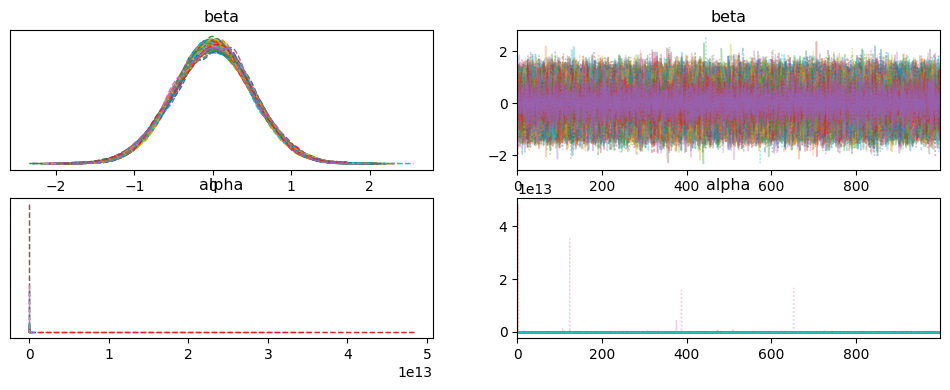

In [116]:
# trace_gk
az.plot_trace(gk_trace, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
gk_summary = az.summary(gk_trace, var_names=["beta"], round_to=2)
gk_summary

In [118]:
gk_feat_importance = get_feature_importance(gk_trace,gk_cols)#
gk_feat_importance

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
48,strength_overall_away_5_ewm,0.015279,negative,0.515500,-0.964057,0.935733
114,team_Liverpool,0.014202,negative,0.511167,-0.974065,0.963809
76,ownership_change_1_ewm,0.011997,negative,0.514333,-0.907182,0.926129
90,transfers_out_5_ewm,0.011248,positive,0.515167,-0.928028,0.945910
100,opp_elo,0.011000,negative,0.508667,-0.929510,0.934171
...,...,...,...,...,...,...
14,expected_goals_conceded_3_ewm,0.000085,positive,0.505000,-0.918520,0.935855
144,was_home_True,0.000081,negative,0.500833,-0.923848,0.930950
73,percenatge_net_transfers_1_ewm,0.000027,negative,0.496167,-0.959998,0.944467
84,pts_bonus_5_ewm,0.000005,negative,0.494833,-0.937776,0.932545


In [120]:
gk_feat_importance[gk_feat_importance['significance_pd'] > .85]

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi


# Before


In [15]:
X, M,Y, players = prepare_data_matrices(active_data_, history_df, working_df.columns.tolist())

In [16]:
trace, scalaer = estimate_opponent_betas_with_market_prior(X, Y, M, use_gpu=True)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,19,0.00,1023
,2000,0,0.07,127
,2000,0,0.00,1023
,2000,0,0.00,1023
,2000,0,0.07,127
,2000,28,0.00,1023


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.37,0.41,-0.34,0.90,0.14,0.05,8.02,69.86,2.04
beta[1],0.15,0.14,-0.08,0.35,0.04,0.01,12.31,69.81,1.42
beta[2],0.32,0.35,-0.07,0.97,0.13,0.07,7.20,16.93,2.54
beta[3],0.34,0.77,-0.99,1.54,0.31,0.19,7.02,6.05,2.74
beta[4],0.68,0.31,0.15,0.99,0.12,0.04,6.80,68.48,3.04
...,...,...,...,...,...,...,...,...,...
beta[196],0.18,0.52,-0.74,0.98,0.19,0.08,7.20,12.78,2.54
beta[197],0.37,0.76,-0.44,1.95,0.31,0.24,6.99,21.02,2.77
beta[198],0.38,0.53,-0.23,1.40,0.21,0.14,7.81,75.30,2.12
beta[199],-0.11,0.52,-0.84,0.72,0.19,0.08,7.92,17.00,2.08


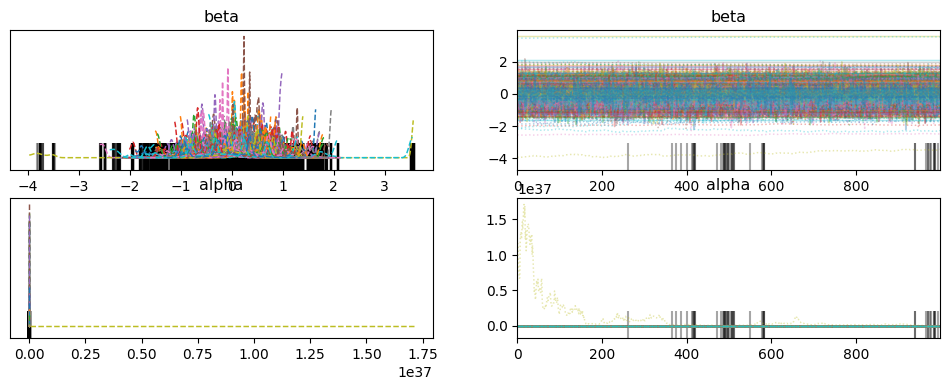

In [17]:
# trace_gk
az.plot_trace(trace, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace, var_names=["beta"], round_to=2)
summary

In [ ]:
feat_importance = get_feature_importance(trace,feats)#['value', 'selected_by_percent', 'transfers_in_3_ewm', 'form_3_ewm', 'ict_index_3_ewm', 'team_h_difficulty', 'win_prob', 'elo'])
feat_importance

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
162,team_Crystal Palace,0.879173,positive,0.997167,0.230218,1.804504
46,tackles_5_ewm,0.849194,positive,0.977500,0.063202,1.497137
4,ownership_change,0.678997,positive,0.992667,0.092364,0.986308
158,team_Brentford,0.625268,negative,0.593000,-3.873469,0.828653
171,team_Spurs,0.598685,positive,0.813667,-0.738039,1.788448
...,...,...,...,...,...,...
45,tackles_3_ewm,0.008202,positive,0.609167,-0.784613,0.929029
48,npxG_3_ewm,0.006626,positive,0.548667,-0.830874,0.929174
190,opponent_team_12.0,0.006237,negative,0.427833,-0.937070,0.596514
125,strength_attack_away_1_ewm,0.005915,negative,0.530000,-1.043842,1.285412


In [22]:
feat_importance[feat_importance['significance_pd'] > .85]

,feature,importance_score,direction,significance_pd,lower_hdi,upper_hdi
162,team_Crystal Palace,0.879173,positive,0.997167,0.230218,1.804504
46,tackles_5_ewm,0.849194,positive,0.977500,0.063202,1.497137
4,ownership_change,0.678997,positive,0.992667,0.092364,0.986308
85,transfers_in_5_ewm,0.594851,positive,0.949000,-0.114874,1.282022
123,ownership_change_3_ewm,0.569628,positive,0.899167,-0.367796,0.918508
114,npg_3_ewm,0.492707,positive,0.914000,-0.273253,0.870743
29,assists_1_ewm,0.491065,positive,0.899167,-0.207841,0.961121
160,team_Burnley,0.476617,negative,0.863167,-1.046159,0.180217
138,xGChain_3_ewm,0.444684,positive,0.889167,-0.404610,0.936062
103,key_passes_5_ewm,0.436804,positive,0.854500,-0.488667,1.060281
